In [8]:
import os
from io import BytesIO
import requests
from datetime import datetime,timedelta
import warnings
import xarray as xr
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
import pandas as pd
import matplotlib.patheffects as path_effects
from matplotlib.colors import ListedColormap
from matplotlib.colorbar import ColorbarBase
import matplotlib.colors as mcolors
import helper_dicts as hdict
import helper_functions as helper
%load_ext autoreload
%autoreload 2
import cftime
import dask
import rioxarray
from dateutil.relativedelta import relativedelta

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
figure_dir = '/cpc/int_desk/pac_isl/stations/images'
gefs_dir = '/cpc/africawrf/ebekele/cca/xcast/subseason/prep_data/data/' #this has the masked versions need to find unmasked
nmme_dir = '/cpc/fews/production/NMME/inputs/filtered/netcdf/ncout'
gefs_dir = '/cpc/fews/production/GEFS/output/bin'
cdas_dir = '/cpc/data/cdas/rot_daily/pgb.20241124.grb2'

In [6]:
xr.open_dataset(cdas_dir, engine = 'cfgrib')

ValueError: unrecognized engine cfgrib must be one of: ['netcdf4', 'h5netcdf', 'scipy', 'rasterio', 'store']

In [3]:
gefs_daily = xr.open_mfdataset('/cpc/africawrf/ebekele/projects/PREPARE_pacific/notebooks/unmasked/*.nc')

OSError: no files to open

In [96]:
gefs_try = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_raw_20241121.nc'))

In [96]:
gefs_try = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_raw_20241121.nc'))

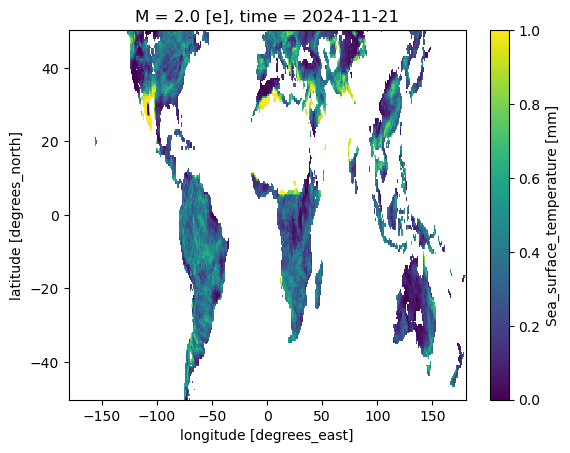

In [97]:
gefs_try.precip.isel(M=1).plot()

In [85]:
nmme_fcst = xr.open_dataset(os.path.join(nmme_dir, 'nmme_prate_ensmean_fcst.nc'), engine = 'netcdf4', decode_times=False)
nmme_hcst =  xr.open_dataset(os.path.join(nmme_dir, 'nmme_prate_ensmean_hcst.nc'), engine = 'netcdf4', decode_times=False)
start_date = datetime(1991,1,1)

In [86]:
# Function to convert months to dates
def convert_months_to_dates(months, start_date):
    return [start_date + relativedelta(months=+m) for m in months]

def convert_mms_to_mmmonth(ds):
    fcst_month = np.array(dates_of_interest[0])
    fcst_month = fcst_month.astype('datetime64[M]').astype(int) % 12 + 1
    if fcst_month in [1,3,5,7,8,10,12]:
        days_in_month = 31
    elif fcst_month in [4,6,9,11]:
        days_in_month = 30
    elif fcst_month in [2]:
        days_in_month = 28
    ds_month = ds*60*60*24*days_in_month #update to mm/month
    return(ds_month)

In [92]:
print(len(nmme_hcst.time.values))

30


In [93]:
start_date = datetime(1991,1,1)
dates_of_interest = convert_months_to_dates(range(0,31), start_date)
print(dates_of_interest)
nmme_dates = []
for d, date in enumerate(dates_of_interest):
    nmme_date = nmme_hcst.isel(time = d)
    nmme_date = nmme_date.expand_dims({'time': [dates_of_interest[d]]})
    nmme_dates.append(nmme_date)
    
nmme_dates = xr.concat(nmme_dates, dim = 'time')
print(nmme_dates)


#update mm/s to mm/month
# raw_season_month = convert_mms_to_mmmonth(raw_season_times)

[datetime.datetime(1991, 1, 1, 0, 0), datetime.datetime(1991, 2, 1, 0, 0), datetime.datetime(1991, 3, 1, 0, 0), datetime.datetime(1991, 4, 1, 0, 0), datetime.datetime(1991, 5, 1, 0, 0), datetime.datetime(1991, 6, 1, 0, 0), datetime.datetime(1991, 7, 1, 0, 0), datetime.datetime(1991, 8, 1, 0, 0), datetime.datetime(1991, 9, 1, 0, 0), datetime.datetime(1991, 10, 1, 0, 0), datetime.datetime(1991, 11, 1, 0, 0), datetime.datetime(1991, 12, 1, 0, 0), datetime.datetime(1992, 1, 1, 0, 0), datetime.datetime(1992, 2, 1, 0, 0), datetime.datetime(1992, 3, 1, 0, 0), datetime.datetime(1992, 4, 1, 0, 0), datetime.datetime(1992, 5, 1, 0, 0), datetime.datetime(1992, 6, 1, 0, 0), datetime.datetime(1992, 7, 1, 0, 0), datetime.datetime(1992, 8, 1, 0, 0), datetime.datetime(1992, 9, 1, 0, 0), datetime.datetime(1992, 10, 1, 0, 0), datetime.datetime(1992, 11, 1, 0, 0), datetime.datetime(1992, 12, 1, 0, 0), datetime.datetime(1993, 1, 1, 0, 0), datetime.datetime(1993, 2, 1, 0, 0), datetime.datetime(1993, 3, 1, 0

IndexError: index 30 is out of bounds for axis 0 with size 30

In [11]:
stations = [{'name': 'Chuuk-Weno_FSM','lat': 7.45, 'lon': 151.85 },
            { 'name': 'Colonia-Yap_FSM', 'lat': 9.52, 'lon': 138.13 },
            { 'name': 'Lukunor_FSM', 'lat': 5.502, 'lon': 153.817 },
            { 'name': 'Kolonia-Pohnpei_FSM', 'lat': 6.984, 'lon': 158.207 },
            { 'name': 'Kosrae_FSM', 'lat': 5.326, 'lon': 163.011 },
            { 'name': 'Palikir-Pohnpei_FSM', 'lat': 6.923, 'lon': 158.159 },
            { 'name': 'Abaiang_Kiribati', 'lat': 1.799, 'lon': 173.039 },
            { 'name': 'Beru_Kiribati', 'lat': -1.337, 'lon': 175.996 },
            { 'name': 'Butaritari_Kiribati', 'lat': 3.072, 'lon': 172.792 },
            { 'name': 'Tarawa_Kiribati', 'lat': 1.382, 'lon': 173.147 }, 
            { 'name': 'Fanning_Kiribati', 'lat': 3.898, 'lon': (-159.386 + 360) % 360 }, 
            { 'name': 'Kirimati_Kiribati', 'lat': 1.986, 'lon': (-157.35 + 360) % 360 }, 
            { 'name': 'Washington_Kiribati', 'lat': 4.692, 'lon': (-160.408 + 360) % 360 }, 
            { 'name': 'Canton_Kiribati', 'lat': -2.769, 'lon': (-171.718 + 360) % 360 }, 
            { 'name': 'Koror_Palau', 'lat': 7.342, 'lon': 134.476 },
            { 'name': 'Ngerulmud_Palau', 'lat': 7.5, 'lon': 134.624 },
            { 'name': 'Alotau_PNG', 'lat': -10.314, 'lon': 150.458 },
            { 'name': 'Kavieng_PNG', 'lat': -2.581, 'lon': 150.806 },
            { 'name': 'Lae_PNG', 'lat': -6.728, 'lon': 146.996 },
            { 'name': 'Madang_PNG', 'lat': -5.225, 'lon': 145.792 },
            { 'name': 'Mendi_PNG', 'lat': -6.145, 'lon': 143.657 },
            { 'name': 'Mount-Hagen_PNG', 'lat': -5.859, 'lon': 144.235 },
            { 'name': 'Popondetta_PNG', 'lat': -8.764, 'lon': 148.239 },
            { 'name': 'Port Moresby_PNG', 'lat': -9.439, 'lon': 147.211 },
            { 'name': 'Tari_PNG', 'lat': -5.851, 'lon': 142.95 },
            { 'name': 'Wewak_PNG', 'lat': -3.584, 'lon': 143.669 },
            { 'name': 'Goroka_PNG', 'lat': -6.075, 'lon': 145.392 },
            { 'name': 'Vanimo_PNG', 'lat': -2.688, 'lon': 141.299 },
            { 'name': 'Nadzab_PNG', 'lat': -6.566, 'lon': 146.73 },
            { 'name': 'Tokua_PNG', 'lat': -4.343, 'lon': 152.377 },
            { 'name': 'Apia_Samoa', 'lat': -13.846, 'lon': (-171.763 + 360) % 360 },
            { 'name': 'Afega_Samoa', 'lat': -13.8, 'lon': (-171.853 + 360) % 360 },
            { 'name': 'Safotu_Samoa', 'lat': -13.452, 'lon': (-172.408 + 360) % 360 },
            { 'name': 'Leulumoega_Samoa', 'lat': -13.827, 'lon': (-171.961 + 360) % 360 },
            { 'name': 'Asau_Samoa', 'lat': -13.528, 'lon': (-172.628 + 360) % 360 },
            { 'name': 'Lufilufi_Samoa', 'lat': -13.874, 'lon': (-171.6 + 360) % 360 },
            { 'name': 'Vailoa_Samoa', 'lat': -13.755, 'lon': (-172.307 + 360) % 360 },
            { 'name': 'Saleaula_Samoa', 'lat': -13.449, 'lon': (-172.337 + 360) % 360 },
            { 'name': 'Samamea_Samoa', 'lat': -13.934, 'lon': (-171.532 + 360) % 360 },
            { 'name': 'Auki_Solomons', 'lat': -8.768, 'lon': 160.697 },
            { 'name': 'Buala_Solomons', 'lat': -8.146, 'lon': 159.593 },
            { 'name': 'Gizo_Solomons', 'lat': -8.105, 'lon': 156.846 },
            { 'name': 'Honiara_Solomons', 'lat': -9.442, 'lon': 159.983 },
            { 'name': 'Kirakira_Solomons', 'lat': -10.457, 'lon': 161.92 },
            { 'name': 'Lata_Solomons', 'lat': -10.723, 'lon': 165.799 },
            { 'name': 'Tigoa_Solomons', 'lat': -11.551, 'lon': 160.063 },
            { 'name': 'Tulagi_Solomons', 'lat': -9.11, 'lon': 160.152 },
            { 'name': 'Taro_Solomons', 'lat': -6.711, 'lon': 156.396 },
            { 'name': 'Munda_Solomons', 'lat': -8.326, 'lon': 157.267 },
            { 'name': 'Funafuti_Tuvalu', 'lat': -8.524, 'lon': 179.197 },
            { 'name': 'Nui_Tuvalu', 'lat': -7.244, 'lon': 177.147 },
            { 'name': 'Niulakita_Tuvalu', 'lat': -10.79, 'lon': 179.471 },
            { 'name': 'Isangel_Vanuatu', 'lat': -19.541, 'lon': 169.281 },
            { 'name': 'Lakatoro_Vanuatu', 'lat': -16.107, 'lon': 167.419 },
            { 'name': 'Luganville_Vanuatu', 'lat': -15.505, 'lon': 167.22 },
            { 'name': 'Port-Vila_Vanuatu', 'lat': -17.742, 'lon': 168.321 },
            { 'name': 'Sola_Vanuatu', 'lat': -13.873, 'lon': 167.547 },
            { 'name': 'Seratmata_Vanuatu', 'lat': -15.288, 'lon': 167.987 },
            { 'name': 'Aneityum_Vanuatu', 'lat': -20.234, 'lon': 169.781 },
            { 'name': 'Ba_Fiji', 'lat': -17.541, 'lon': 177.671 },
            { 'name': 'Labasa_Fiji', 'lat': -16.432, 'lon': 179.38 },
            { 'name': 'Lami_Fiji', 'lat': -18.112, 'lon': 178.415 },
            { 'name': 'Lautoka_Fiji', 'lat': -17.615, 'lon': 177.454 },
            { 'name': 'Nadi_Fiji', 'lat': -17.753, 'lon': 177.451 },
            { 'name': 'Nakasi_Fiji', 'lat': -18.068, 'lon': 178.524 },
            { 'name': 'Nausori_Fiji', 'lat': -18.03, 'lon': 178.531 },
            { 'name': 'Sigatoka_Fiji', 'lat': -18.142, 'lon': 177.503 },
            { 'name': 'Suva_Fiji', 'lat': -18.135, 'lon': 178.435 },
            { 'name': 'Rotuma_Fiji', 'lat': -12.482, 'lon': 177.071 },
            { 'name': 'Nabouwalu_Fiji', 'lat': -16.998, 'lon': 178.695 },
            { 'name': 'Yasawa_Fiji', 'lat': -16.699, 'lon': 177.575 },
            { 'name': 'Viwa_Fiji', 'lat': -17.149, 'lon': 176.913 },
            { 'name': 'VanuaBalavu_Fiji', 'lat': -17.246, 'lon': (-178.956 + 360) % 360 },
            { 'name': 'Tubou-Lakeba_Fiji', 'lat': -18.236 , 'lon': (-178.812 + 360) % 360 },
            { 'name': 'Vunisea_Fiji', 'lat': -19.047, 'lon': 178.163 }
           ]

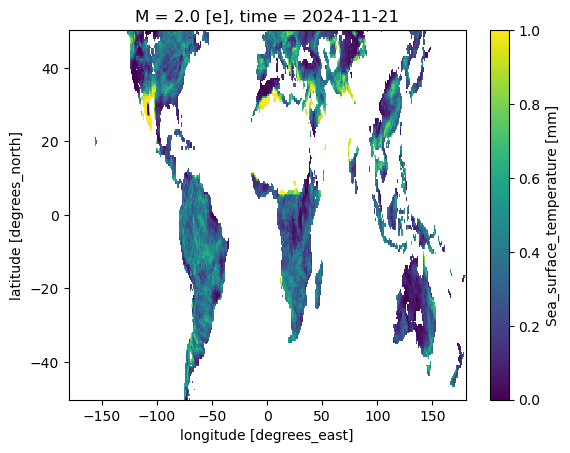

In [36]:
gefswk1 = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_tercile.nc'))
gefswk1.precip.isel(M=1).plot()

In [31]:
gefswk1_stations = []
for s in stations:
    gefswk1_stations.append(gefswk1.sel(lat = s['lat'], lon = s['lon'], method = 'nearest').expand_dims({'station':[s['name']]}))
gefswk1_stations = xr.concat(gefswk1_stations, dim = 'station')

In [35]:
gefswk1_stations.isel(station=2)

<xarray.Dataset>
Dimensions:  (M: 3, time: 1)
Coordinates:
    station  <U11 'Lukunor_FSM'
    lat      float64 5.5
    lon      float64 154.0
  * M        (M) float64 1.0 2.0 3.0
  * time     (time) datetime64[ns] 2024-11-21
Data variables:
    precip   (M, time) float64 nan nan nan